## 1. USO DE APRENDIZAJE NO SUPERVISADO ##

El aprendizaje no supervisado es una rama fundamental en el campo de la inteligencia artificial y el análisis de datos. Se enfoca en identificar patrones y estructuras ocultas en conjuntos de datos sin la necesidad de etiquetas o supervisión externa. Esto lo hace invaluable en problemas de identificación de patrones, donde se busca comprender la estructura subyacente de los datos y descubrir relaciones inherentes entre las variables.

### Dataset: Student Productivity & Behavior Dataset ###

In [57]:
# librerías para uso de aprendizaje no supervisado y PCA
import os
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import seaborn as sns

# descargar dataset Student_productivity
def prepare_data():
    file_path = "data/student_productivity_distraction_dataset_20000.csv"
    _df = pd.read_csv(file_path)
    return _df
df = prepare_data()
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [58]:
# verificar estado de datos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [59]:
#eliminar columna 'student_id' ya que no aporta información relevante para el análisis
df = df.drop(columns=['student_id'])
#eliminar columna "gender" para verificar el peso de las otras variables.
df = df.drop(columns=['gender'])

df.describe()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


### PCA ###

In [60]:
# Escalado de características
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=0.8, random_state=42)  # Mantener el 80% de la varianza
pca_result = pca.fit_transform(scaled_df)

print("Componentes seleccionados:", pca.n_components_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Mostrar la varianza explicada por cada componente de manera vertical
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC {i+1}: {var:.4f}")


Componentes seleccionados: 12
Varianza explicada acumulada: 0.8193121178804421
PC 1: 0.1250
PC 2: 0.0650
PC 3: 0.0648
PC 4: 0.0643
PC 5: 0.0635
PC 6: 0.0635
PC 7: 0.0631
PC 8: 0.0627
PC 9: 0.0624
PC 10: 0.0619
PC 11: 0.0616
PC 12: 0.0615


12 componentes explican el 81.9% de la varianza. Esto indica que las variables del dataset son bastante independientes entre sí.

### A. Ploteo de variables ###

Variables más importantes para cada componente:
PC 1: productivity_score (Importancia: 0.7071)
PC 2: phone_usage_hours (Importancia: 0.3949)
PC 3: final_grade (Importancia: 0.5198)
PC 4: assignments_completed (Importancia: 0.5585)
PC 5: gaming_hours (Importancia: 0.4972)
PC 6: phone_usage_hours (Importancia: 0.4471)
PC 7: exercise_minutes (Importancia: 0.5235)
PC 8: social_media_hours (Importancia: 0.6089)
PC 9: attendance_percentage (Importancia: 0.4901)
PC 10: age (Importancia: 0.4415)
PC 11: stress_level (Importancia: 0.5883)
PC 12: phone_usage_hours (Importancia: 0.6085)


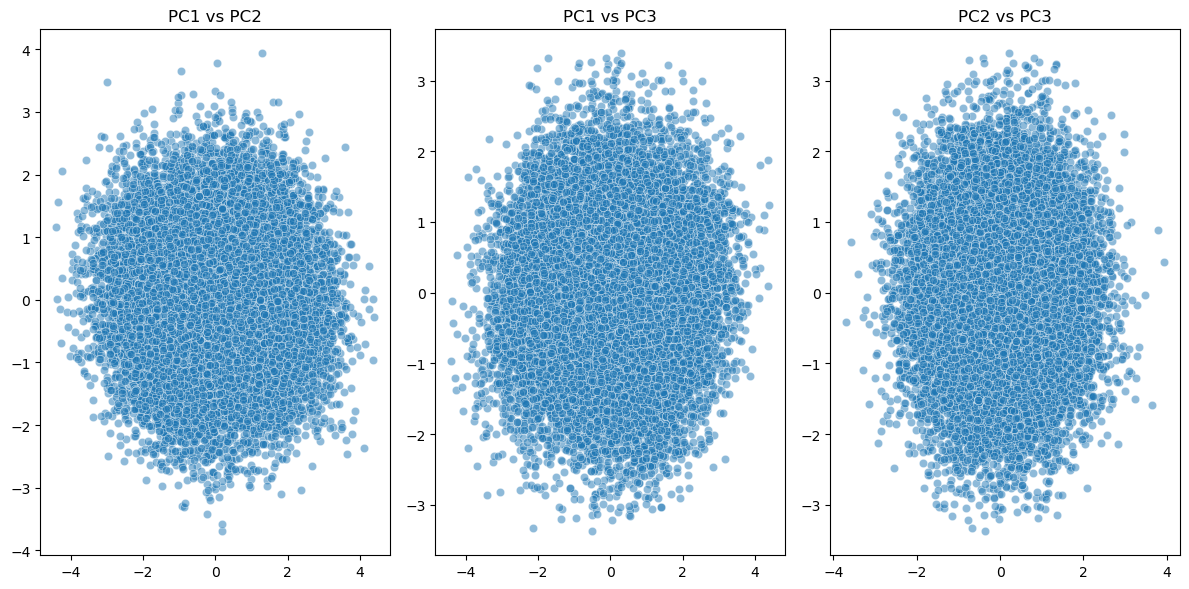

In [61]:
# Nombres de variables más importantes para cada componente
components = pca.components_
print("Variables más importantes para cada componente:")
for i in range(pca.n_components_):
    component = components[i]
    variable_importance = sorted(zip(df.columns, component), key=lambda x: abs(x[1]), reverse=True)
    print(f"PC {i+1}: {variable_importance[0][0]} (Importancia: {variable_importance[0][1]:.4f})")

# Gráfico PC1 vs PC2, PC1 vs PC3 y PC2 vs PC3 en un solo gráfico
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], alpha=0.5)
plt.title('PC1 vs PC2')

plt.subplot(1, 3, 2)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 2], alpha=0.5)
plt.title('PC1 vs PC3')

plt.subplot(1, 3, 3)
sns.scatterplot(x=pca_result[:, 1], y=pca_result[:, 2], alpha=0.5)
plt.title('PC2 vs PC3')

plt.tight_layout()
plt.show()

No existen grupos visibles, no hay separación, no hay forma reconocible. Esto significa que en el espacio de los componentes principales no hay patrones geométricos obvios. 

### Distribución en las 4 variables más importantes considerando PCA ###

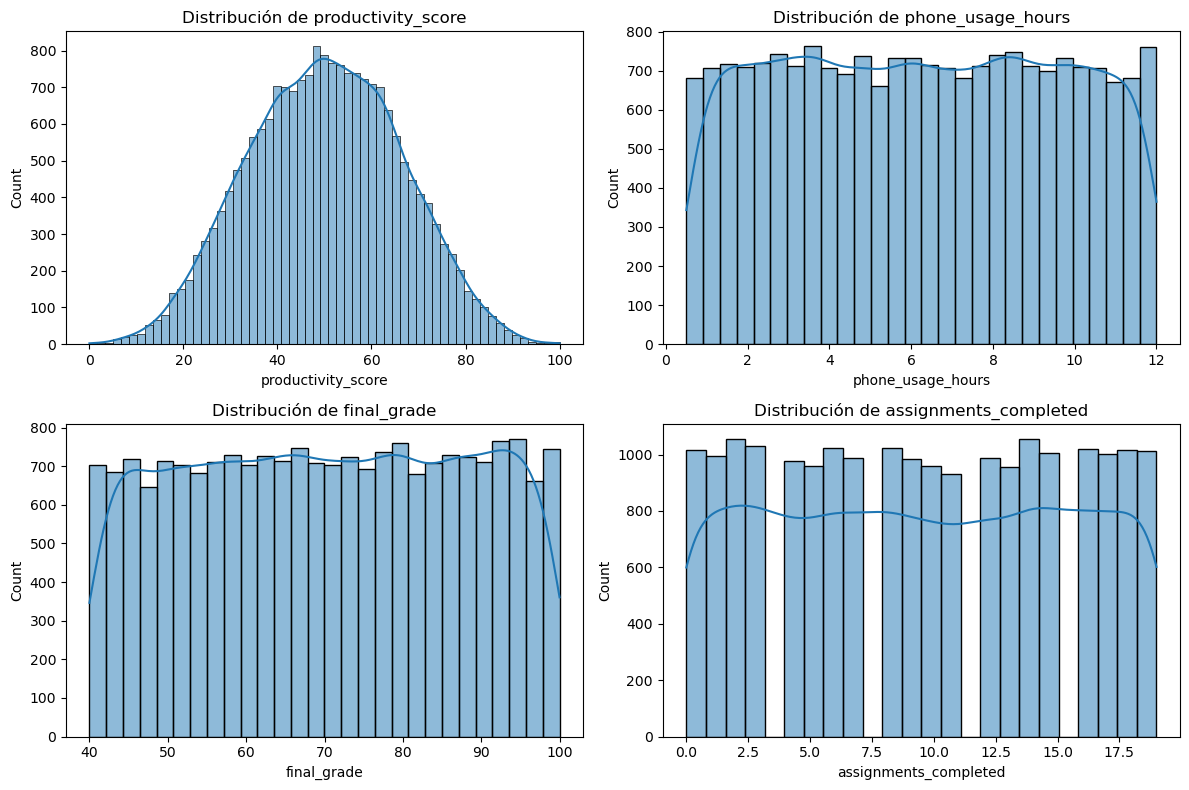

In [62]:
# Graficar distribución de las 4 variables más importantes: productivity_score, phone_usage_hours, final grade y assignment_completion_rate
important_vars = ['productivity_score', 'phone_usage_hours', 'final_grade', 'assignments_completed']
plt.figure(figsize=(12, 8))
for i, var in enumerate(important_vars):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

- productivity_score: Distribución normal (campana de Gauss) centrada alrededor de 50. La mayoría de estudiantes tiene productividad media.
- phone_usage_hours: No existe un patrón claro de uso — todos los valores son igualmente probables.
- final_grade: También uniforme entre 40 y 100. 
- assignments_completed: Uniforme entre 0 y 18.

### B. Patrones/clústeres – análisis univariable ###

Variable a analizar: productivity_score

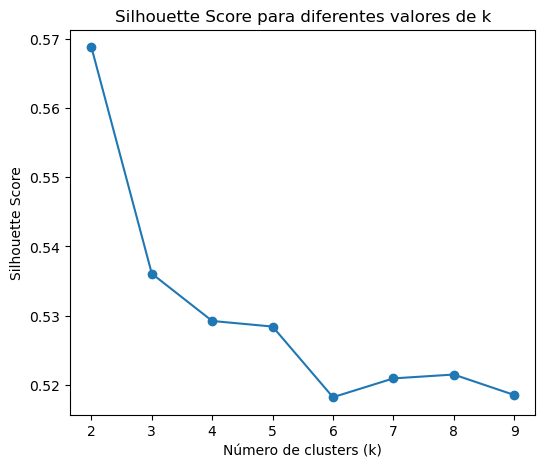

In [75]:
# definir k mediante silhouette score para mi variable productivity_score

from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df[['productivity_score']])
    score = silhouette_score(df[['productivity_score']], labels)
    silhouette_scores.append(score)

# Graficar los silhouette scores
plt.figure(figsize=(6,5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para diferentes valores de k")
plt.show()

Silhouette tiene un resultado de ~0.57, que es un resultado es muy bueno, lo que significa que k=2 es un valor adecuado.

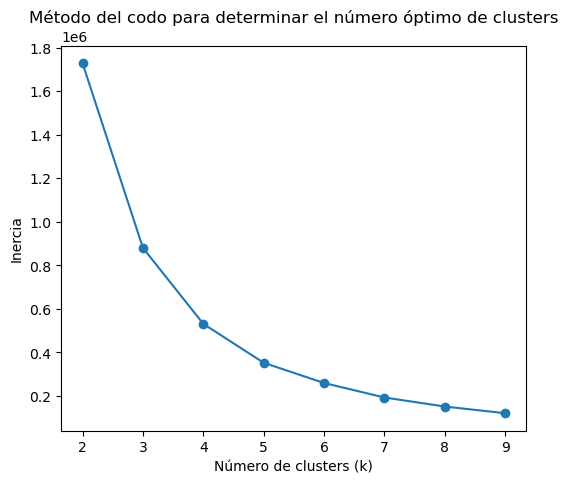

In [76]:
# cálculo de k mediante inercia
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['productivity_score']])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(2, 10), inertia[1:], marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para determinar el número óptimo de clusters")
plt.show()

El método del codo no muestra un punto de inflexión claro, lo que sugiere que productivity_score no tiene grupos naturales muy marcados, tomamos el resultado de Silhouette.

Centroides de los clusters: [[37.0775479 ]
 [63.33580561]]


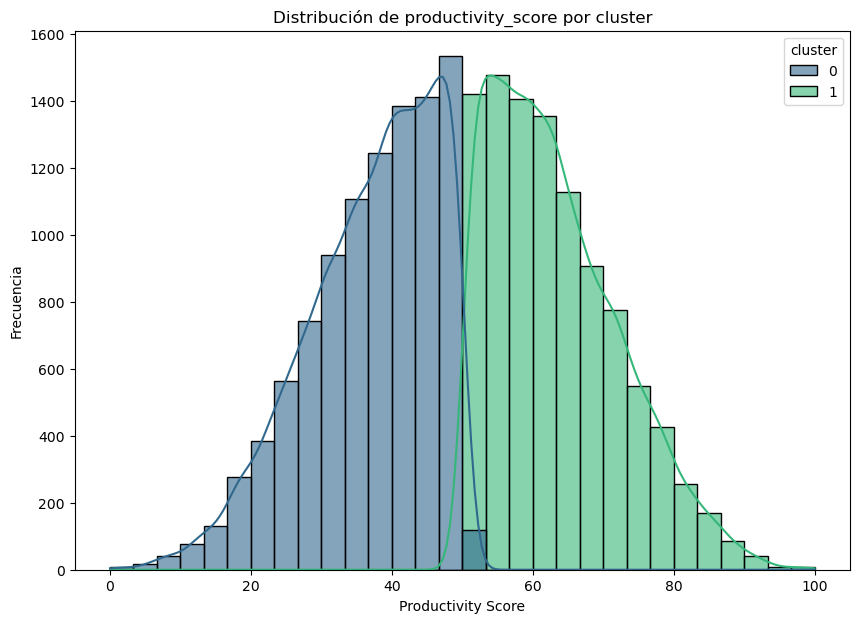

In [66]:
# K-Means para clustering sobre productivity_score
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['productivity_score']])

print("Centroides de los clusters:", kmeans.cluster_centers_)

# Graficar histograma coloreado por cluster
plt.figure(figsize=(10,7))
sns.histplot(
    data=df,
    x='productivity_score',
    hue='cluster',
    bins=30,
    kde=True,
    palette='viridis',
    alpha=0.6
)

plt.title("Distribución de productivity_score por cluster")
plt.xlabel("Productivity Score")
plt.ylabel("Frecuencia")
plt.show()


La división ocurre justo en 50, que es la media de la distribución, ya que productivity_score sigue una distribución normal centrada en 50.

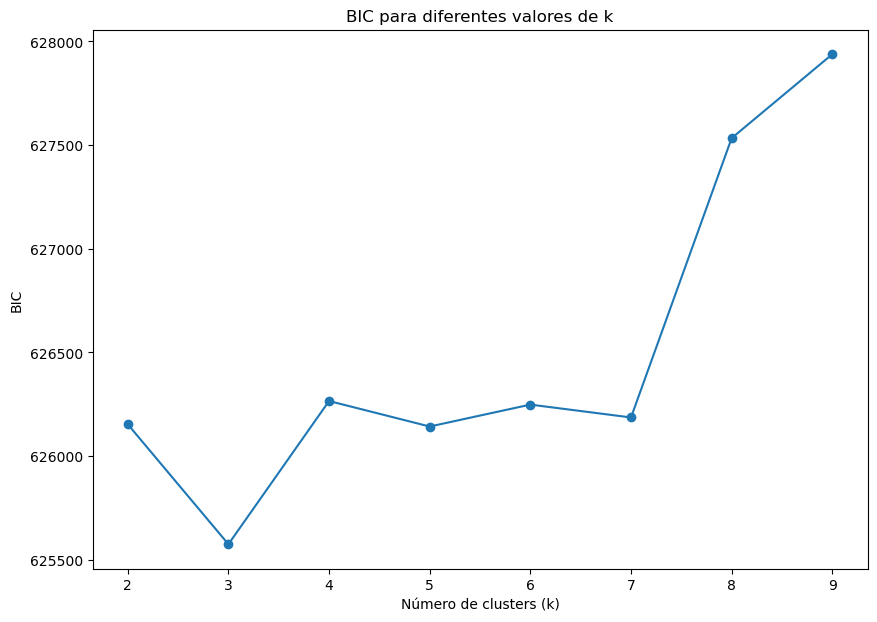

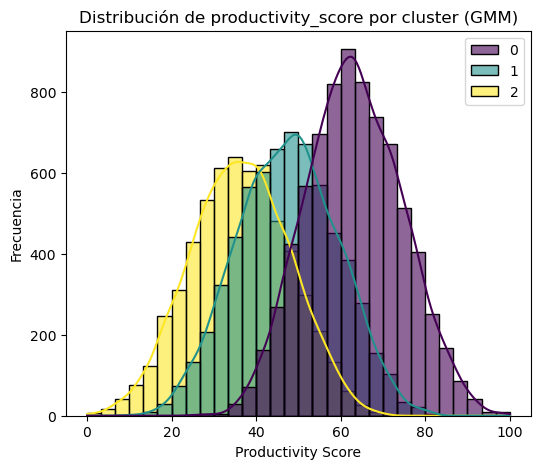

In [77]:
# Código usando GMM para clustering
from sklearn.mixture import GaussianMixture
import numpy as np

k_range = range(2, 10)
bic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(scaled_df)
    bic_scores.append(gmm.bic(scaled_df))

mejor_k_gmm = list(k_range)[np.argmin(bic_scores)]
# graficar BIC scores
plt.figure(figsize=(10,7))
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("BIC")
plt.title("BIC para diferentes valores de k")
plt.show()

# Aplicar GMM con el mejor k
gmm_final = GaussianMixture(n_components=mejor_k_gmm, random_state=42)
gmm_final.fit(scaled_df)
etiquetas_gmm = gmm_final.predict(scaled_df)

# También puedes ver las probabilidades de pertenencia
probabilidades = gmm_final.predict_proba(scaled_df)
# probabilidades[i] = [0.8, 0.2] → el estudiante i tiene 80% de ser clúster 0 y 20% de ser clúster 1

# Graficar histograma coloreado por cluster usando GMM
plt.figure(figsize=(6,5))  
sns.histplot(
    data=df,
    x='productivity_score',
    hue=etiquetas_gmm,
    bins=30,
    kde=True,
    palette='viridis',
    alpha=0.6
)
plt.title("Distribución de productivity_score por cluster (GMM)")
plt.xlabel("Productivity Score")
plt.ylabel("Frecuencia")
plt.show()

GMM con BIC sugiere k=3, identificando además un grupo intermedio. Dado que GMM captura mejor la naturaleza continua de la distribución normal de productivity_score y su BIC tiene un mínimo claro, se adopta k=3 como resultado final. Los tres patrones encontrados son: estudiantes de baja productividad (0–40), media productividad (25–60) y alta productividad (45–100).

### C. Anomalías – análisis univariable ###

Se usa Z-score para detección de anomalías, ya que fue diseñado específicamente para detectar valores atípicos.

Anomalías detectadas: 10
Valores anómalos:
count     10.000000
mean      50.076000
std       51.875799
min        0.000000
25%        0.777500
50%       50.175000
75%       99.285000
max      100.000000
Name: productivity_score, dtype: float64


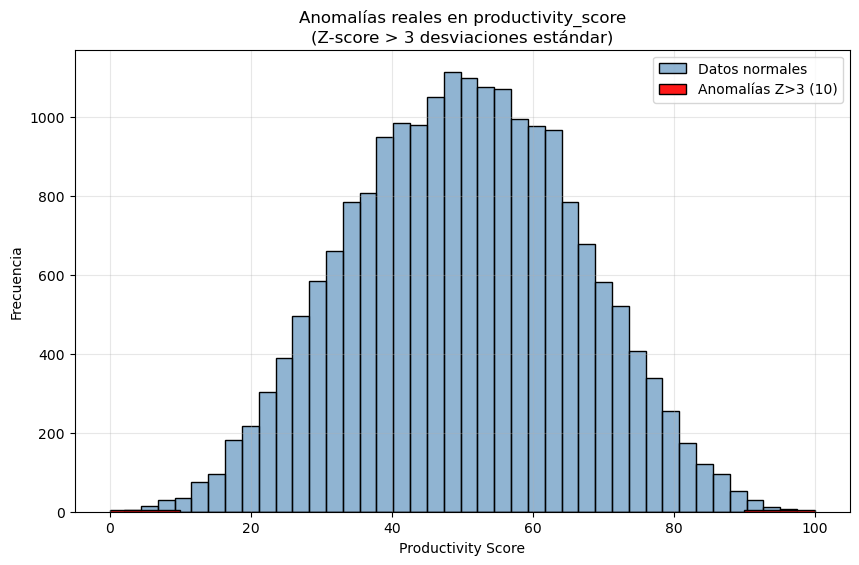

In [82]:
import scipy.stats as stats

# Calcular Z-score para cada valor
z_scores = np.abs(stats.zscore(df['productivity_score']))

# Anomalías = valores más allá de 3 desviaciones estándar
es_anomalia = z_scores > 3

print(f"Anomalías detectadas: {es_anomalia.sum()}")
print(f"Valores anómalos:")
print(df['productivity_score'][es_anomalia].describe())

# Gráfica
plt.figure(figsize=(10, 6))
sns.histplot(df['productivity_score'][~es_anomalia], bins=40,
             color='steelblue', alpha=0.6, label='Datos normales')
sns.histplot(df['productivity_score'][es_anomalia], bins=10,
             color='red', alpha=0.9, label=f'Anomalías Z>3 ({es_anomalia.sum()})')
plt.title("Anomalías reales en productivity_score\n(Z-score > 3 desviaciones estándar)")
plt.xlabel("Productivity Score")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El Z-score detectó únicamente 10 anomalías en 20,000 estudiantes (0.05%), ubicadas en los extremos de la distribución normal de productivity_score.